# Strategy Statistics and Evaluation
## Week 3 – Tuesday 7 April

Focusing on analysis, not signal creation

Step 1 - Load libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline

Step 2 - Load the strategy data

In [2]:
spy = pd.read_csv('/Users/Sinthu/Desktop/(Quant Trading Project)/data/spy.csv', parse_dates=['Date'], date_format='%m/%d/%y', index_col='Date')   # change if needed
spy.columns = spy.columns.str.strip()

spy = pd.DataFrame({'Adj_Close': spy['Close']})

spy.sort_index(inplace=True)
spy.head()

,Adj_Close
Date,
1993-01-29,43.9375
1993-02-01,44.2500
1993-02-02,44.3438
1993-02-03,44.8125
1993-02-04,45.0000


Step 3 - Rebuild or confirm returns

In [3]:
spy["simple_return"] = spy["Adj_Close"].pct_change()
spy = spy.dropna(subset=["simple_return"])

In [4]:
#MA Strategy

short_window = 50
long_window = 200

spy["ma_short"] = spy["Adj_Close"].rolling(short_window).mean()
spy["ma_long"] = spy["Adj_Close"].rolling(long_window).mean()
spy["signal_raw"] = (spy["ma_short"] > spy["ma_long"]).astype(int)
spy["signal"] = spy["signal_raw"].shift(1)
spy["trade"] = spy["signal"].diff().abs().fillna(0)

transaction_cost = 0.001
spy["strategy_return_gross"] = spy["signal"] * spy["simple_return"]
spy["strategy_return_net"] = spy["strategy_return_gross"] - spy["trade"] * transaction_cost

spy["equity_bh"] = (1 + spy["simple_return"]).cumprod()
spy["equity_gross"] = (1 + spy["strategy_return_gross"]).cumprod()
spy["equity_net"] = (1 + spy["strategy_return_net"]).cumprod()

Step 4 - Build core statisitc functions

In [5]:
def annualized_return(r):
    return (1 + r.mean())**252 - 1

def annualized_vol(r):
    return r.std() * np.sqrt(252)

def sharpe_ratio(r):
    vol = annualized_vol(r)
    return np.nan if vol == 0 else annualized_return(r) / vol

def max_drawdown(equity):
    return (equity / equity.cummax() - 1).min()

def hit_rate(r):
    r = r.dropna()
    return (r > 0).mean()

def avg_win(r):
    wins = r[r > 0]
    return wins.mean() if len(wins) > 0 else np.nan

def avg_loss(r):
    losses = r[r < 0]
    return losses.mean() if len(losses) > 0 else np.nan

## New statistics functions added

- Hit rate = fraction of positive return days.
- Average win/loss = average size of winning and losing days

These new functions help to understand the shape of returns and not just the headline of the sharpe. Giving us an indepth understanding.

Step 5 - Make the summary table

In [6]:
summary = pd.DataFrame({
    "Buy & Hold": [
        annualized_return(spy["simple_return"]),
        annualized_vol(spy["simple_return"]),
        sharpe_ratio(spy["simple_return"]),
        max_drawdown(spy["equity_bh"]),
        hit_rate(spy["simple_return"]),
        avg_win(spy["simple_return"]),
        avg_loss(spy["simple_return"])
    ],
    "MA Gross": [
        annualized_return(spy["strategy_return_gross"]),
        annualized_vol(spy["strategy_return_gross"]),
        sharpe_ratio(spy["strategy_return_gross"]),
        max_drawdown(spy["equity_gross"]),
        hit_rate(spy["strategy_return_gross"]),
        avg_win(spy["strategy_return_gross"]),
        avg_loss(spy["strategy_return_gross"])
    ],
    "MA Net": [
        annualized_return(spy["strategy_return_net"]),
        annualized_vol(spy["strategy_return_net"]),
        sharpe_ratio(spy["strategy_return_net"]),
        max_drawdown(spy["equity_net"]),
        hit_rate(spy["strategy_return_net"]),
        avg_win(spy["strategy_return_net"]),
        avg_loss(spy["strategy_return_net"])
    ]
}, index=[
    "Annual Return",
    "Annual Volatility",
    "Sharpe",
    "Max Drawdown",
    "Hit Rate",
    "Average Win",
    "Average Loss"
])

summary.round(4)

,Buy & Hold,MA Gross,MA Net
Annual Return,0.1044,0.0878,0.0868
Annual Volatility,0.1862,0.1346,0.1346
Sharpe,0.5607,0.6523,0.6448
Max Drawdown,-0.5647,-0.3410,-0.3410
Hit Rate,0.5360,0.3991,0.3990
Average Win,0.0077,0.0066,0.0066
Average Loss,-0.0081,-0.0070,-0.0070


Step 6 - Plot daily returns

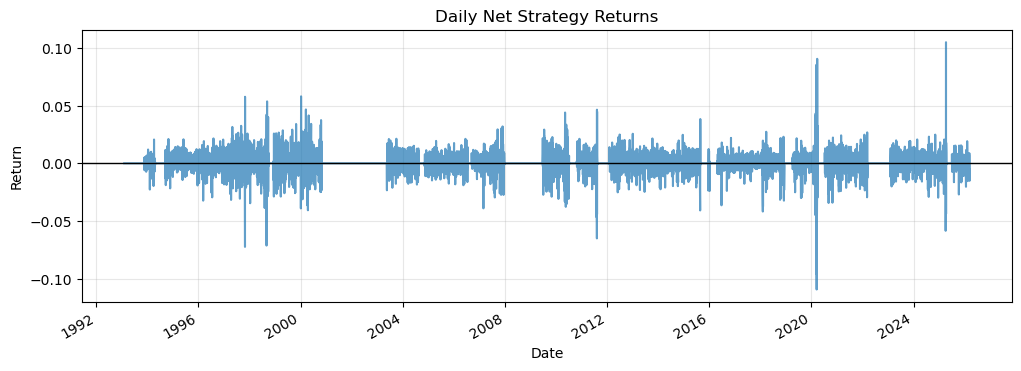

In [7]:
plt.figure(figsize=(12,4))
spy["strategy_return_net"].plot(title="Daily Net Strategy Returns", alpha=0.7)
plt.axhline(0, color="black", linewidth=1)
plt.ylabel("Return")
plt.grid(True, alpha=0.3)
plt.show()

- Clear to see clusters of returns, however during these clusters returns are smooth throughout.
- Only a handful of spikes in returns - possible to tweak strategy to improve these spikes and to prevent clusters

Step 7 - Rolling volatility

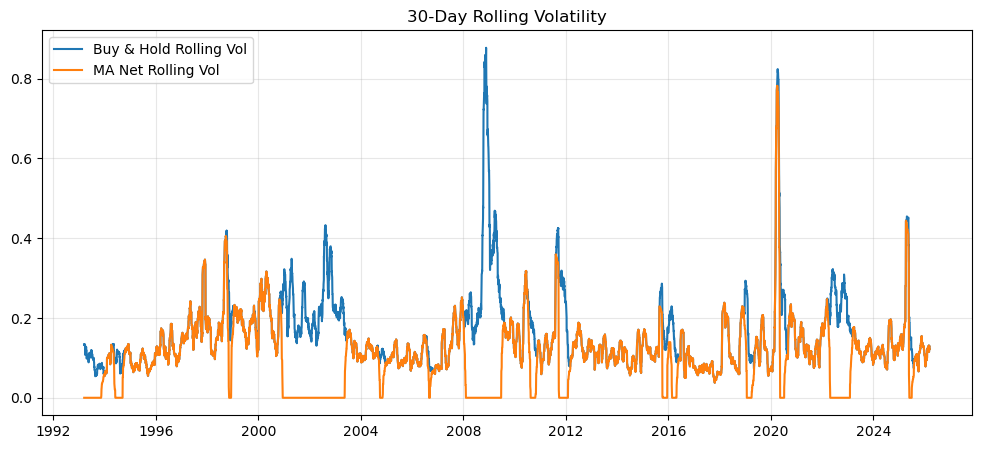

In [8]:
window = 30

spy["roll_vol_bh"] = spy["simple_return"].rolling(window).std() * np.sqrt(252)
spy["roll_vol_net"] = spy["strategy_return_net"].rolling(window).std() * np.sqrt(252)

plt.figure(figsize=(12,5))
plt.plot(spy.index, spy["roll_vol_bh"], label="Buy & Hold Rolling Vol")
plt.plot(spy.index, spy["roll_vol_net"], label="MA Net Rolling Vol")
plt.title("30-Day Rolling Volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

- Volatility does not rise during stressful periods in the early 2000s and 2008 crashes, showing good signs the strategy can step away. However, during the covid crash volaitlity increases same as the 'Buy and Hold' method
- 'MA Average' method does reduce risk relative to 'Buy and Hold' Method
- The strategy becomes unstable during the covid crash, oil price increases during Russian/ Ukraine war and current US-Israel/ Iran war

Step 8 - Rolling Sharpe

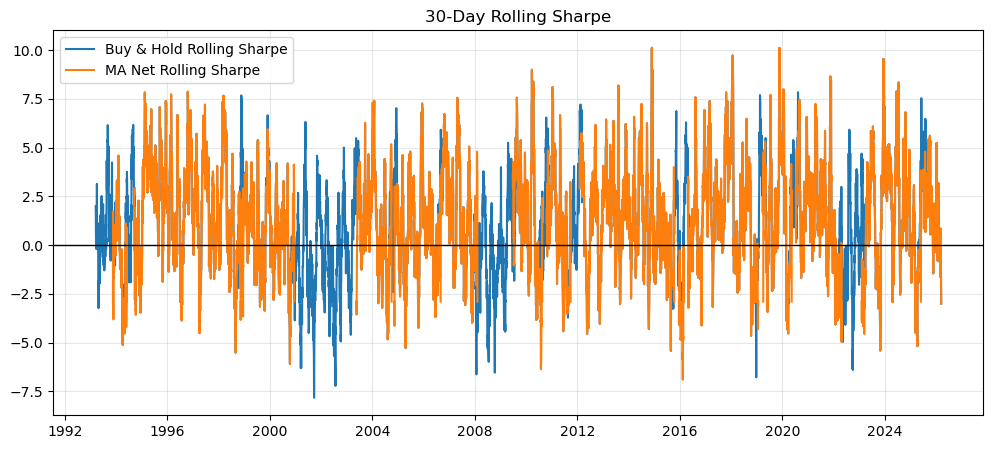

In [9]:
def rolling_sharpe(returns, window=30):
    return returns.rolling(window).mean() / returns.rolling(window).std() * np.sqrt(252)

spy["roll_sharpe_bh"] = rolling_sharpe(spy["simple_return"], window)
spy["roll_sharpe_net"] = rolling_sharpe(spy["strategy_return_net"], window)

plt.figure(figsize=(12,5))
plt.plot(spy.index, spy["roll_sharpe_bh"], label="Buy & Hold Rolling Sharpe")
plt.plot(spy.index, spy["roll_sharpe_net"], label="MA Net Rolling Sharpe")
plt.axhline(0, color="black", linewidth=1)
plt.title("30-Day Rolling Sharpe")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Step 9 - Max drawdown plot

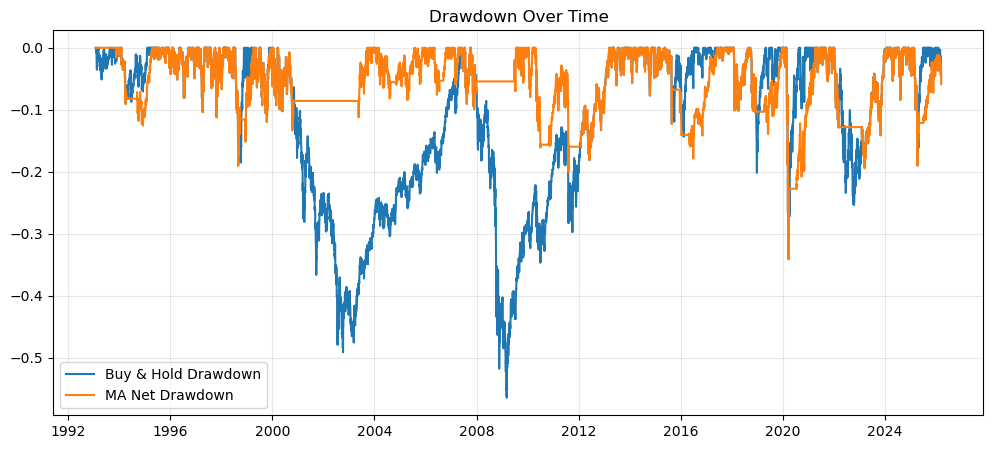

In [10]:
dd_bh = spy["equity_bh"] / spy["equity_bh"].cummax() - 1
dd_net = spy["equity_net"] / spy["equity_net"].cummax() - 1

plt.figure(figsize=(12,5))
plt.plot(spy.index, dd_bh, label="Buy & Hold Drawdown")
plt.plot(spy.index, dd_net, label="MA Net Drawdown")
plt.title("Drawdown Over Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

- Clear benefits shown in the MA net method as drawdown kept consitent throughout
- Manages to avoid the big crashes however, during recent times post covid - we see slight drawdown spikes

Step 10 - Hypothesis test on returns

In [11]:
strategy_r = spy["strategy_return_net"].dropna()

t_stat, p_value = stats.ttest_1samp(strategy_r, 0)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

T-statistic: 3.5576
P-value: 0.0004


In [12]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis: mean strategy return is significantly different from zero.")
else:
    print("Fail to reject the null hypothesis: no strong evidence that mean strategy return differs from zero.")

Reject the null hypothesis: mean strategy return is significantly different from zero.


- The t-test does NOT prove the strategy is good
- It lets you know if the average return is statistically different from 0 unders this sample test

Step 11 - Compare with buy and hold statistically

In [14]:
bh_r = spy["simple_return"].dropna()
t_stat_bh, p_value_bh = stats.ttest_1samp(bh_r, 0)

print(f"Buy & Hold t-statistic: {t_stat_bh:.4f}")
print(f"Buy & Hold p-value: {p_value_bh:.4f}")

Buy & Hold t-statistic: 3.0689
Buy & Hold p-value: 0.0022


## Tuesday interpretation

Which metric looks strongest?
- Drawdown over time

Is the strategy volatile?
- The strategy is highly volatile, higher than it should be for a trend following method
  
Is the drawdown manageable?
- Yes, fairly manageable, lower than buy and hold method

Is the rolling Sharpe stable?
- No

Does the t-test suggest any evidence of positive mean return?
- Yes, shows evidence of positive mean return

Would you trust this yet? Why or why not?-
- No, as it is inconsitient and has several issues. The return is not worth the high volatility

# Wednesday 8 April – Rolling Analysis